In [2]:
import numpy as np
import pandas as pd

def optimize_bio_spray_blend(formulation_candidates):
    """
    Optimizes a bio-spray hair oil formulation by scoring candidates
    based on viscosity, spreadability index, and active compound retention.
    """
    results = []
    for candidate in formulation_candidates:
        name = candidate['name']
        viscosity = candidate['viscosity_cp'] # Target: low for micro-mist spray (< 30 cP)
        spreadability = candidate['spreadability_index'] # Fixed key name here!
        active_load = candidate['active_load_pct']

        # Scoring function balancing low viscosity for spray mechanics and high active load for efficacy
        score = (spreadability * 0.4) + (active_load * 0.4) - (max(0, viscosity - 25) * 0.2)

        results.append({
            'Formulation': name,
            'Viscosity (cP)': viscosity,
            'Spreadability Index': spreadability,
            'Active Load (%)': active_load,
            'Optimization Score': round(score, 2)
        })

    df = pd.DataFrame(results)
    return df.sort_values(by='Optimization Score', ascending=False)

# Sample candidate formulations combining light carrier oils and botanical nano-actives
candidates = [
    {'name': 'Blend A: Squalane + Pea Sprout Extract', 'viscosity_cp': 18.5, 'spreadability_index': 9.2, 'active_load_pct': 5.0},
    {'name': 'Blend B: Jojoba + Resveratrol Nanovesicles', 'viscosity_cp': 24.0, 'spreadability_index': 8.5, 'active_load_pct': 7.5},
    {'name': 'Blend C: Fractionated Coconut + Coffee Extract', 'viscosity_cp': 15.0, 'spreadability_index': 9.8, 'active_load_pct': 3.0},
]

optimized_df = optimize_bio_spray_blend(candidates)
print("--- Bio-Spray Oil Formulation Optimization Results ---")
print(optimized_df)

--- Bio-Spray Oil Formulation Optimization Results ---
                                      Formulation  Viscosity (cP)  \
1      Blend B: Jojoba + Resveratrol Nanovesicles            24.0   
0          Blend A: Squalane + Pea Sprout Extract            18.5   
2  Blend C: Fractionated Coconut + Coffee Extract            15.0   

   Spreadability Index  Active Load (%)  Optimization Score  
1                  8.5              7.5                6.40  
0                  9.2              5.0                5.68  
2                  9.8              3.0                5.12  


In [5]:
def optimize_and_predict_formulations(candidates, model):
    """
    Predicts follicular penetration and calculates an overall optimization score.
    """
    df_candidates = pd.DataFrame(candidates)

    # Predict penetration efficiency using our trained ML model
    features = df_candidates[['Droplet_Size_nm', 'Viscosity_cP', 'Active_Load_pct']]
    df_candidates['Predicted_Penetration_pct'] = np.round(model.predict(features), 2)

    # Fixed: Use np.maximum instead of built-in max() to handle Pandas Series element-wise
    df_candidates['Optimization_Score'] = np.round(
        (df_candidates['Predicted_Penetration_pct'] * 0.5) +
        (df_candidates['Active_Load_pct'] * 3.0) -
        (np.maximum(0, df_candidates['Viscosity_cP'] - 25) * 0.5), 2
    )

    return df_candidates.sort_values(by='Optimization_Score', ascending=False)

In [7]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 103.0 MB/s eta 0:00:00


In [8]:
!pip install streamlit

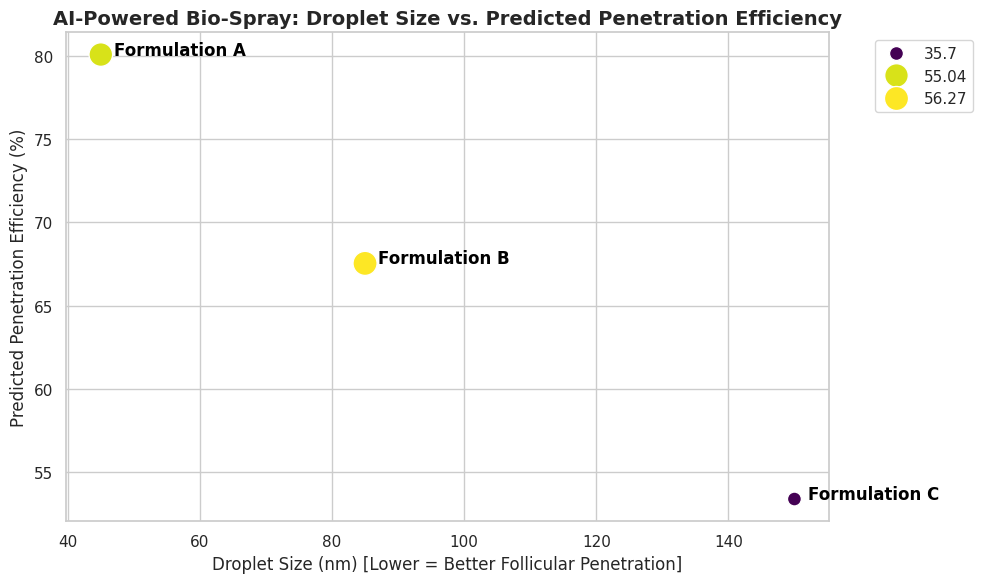

✅ Results successfully plotted and saved to 'bio_spray_optimized_formulations.csv'!


In [10]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Train the model function
def train_penetration_predictor():
    np.random.seed(42)
    n_samples = 200
    droplet_sizes = np.random.uniform(20, 300, n_samples)
    viscosities = np.random.uniform(10, 40, n_samples)
    active_loads = np.random.uniform(1, 10, n_samples)

    penetration_efficiency = (
        100
        - (droplet_sizes * 0.25)
        - (viscosities * 0.8)
        + (active_loads * 1.5)
        + np.random.normal(0, 2, n_samples)
    )
    penetration_efficiency = np.clip(penetration_efficiency, 10, 98)

    X = pd.DataFrame({
        'Droplet_Size_nm': droplet_sizes,
        'Viscosity_cP': viscosities,
        'Active_Load_pct': active_loads
    })
    y = pd.Series(penetration_efficiency)

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    return model

# 2. Create results_df
ml_model = train_penetration_predictor()

candidates = [
    {'Name': 'Formulation A: Squalane + Pea Sprout Nanovesicles', 'Droplet_Size_nm': 45.0, 'Viscosity_cP': 18.5, 'Active_Load_pct': 5.0},
    {'Name': 'Formulation B: Jojoba + Resveratrol Nanoemulsion', 'Droplet_Size_nm': 85.0, 'Viscosity_cP': 24.0, 'Active_Load_pct': 7.5},
    {'Name': 'Formulation C: Fractionated Coconut + Coffee Extract', 'Droplet_Size_nm': 150.0, 'Viscosity_cP': 15.0, 'Active_Load_pct': 3.0},
]

df_candidates = pd.DataFrame(candidates)
df_candidates['Predicted_Penetration_pct'] = np.round(ml_model.predict(df_candidates[['Droplet_Size_nm', 'Viscosity_cP', 'Active_Load_pct']]), 2)
df_candidates['Optimization_Score'] = np.round(
    (df_candidates['Predicted_Penetration_pct'] * 0.5) +
    (df_candidates['Active_Load_pct'] * 3.0) -
    (np.maximum(0, df_candidates['Viscosity_cP'] - 25) * 0.5), 2
)
results_df = df_candidates.sort_values(by='Optimization_Score', ascending=False).reset_index(drop=True)

# 3. Plotting Penetration Efficiency vs Optimization Score
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

scatter = sns.scatterplot(
    data=results_df,
    x='Droplet_Size_nm',
    y='Predicted_Penetration_pct',
    size='Optimization_Score',
    hue='Optimization_Score',
    palette='viridis',
    sizes=(100, 300),
    legend='full'
)

plt.title('AI-Powered Bio-Spray: Droplet Size vs. Predicted Penetration Efficiency', fontsize=14, fontweight='bold')
plt.xlabel('Droplet Size (nm) [Lower = Better Follicular Penetration]', fontsize=12)
plt.ylabel('Predicted Penetration Efficiency (%)', fontsize=12)

for line in range(0, results_df.shape[0]):
    plt.text(
        results_df.loc[line, 'Droplet_Size_nm'] + 2,
        results_df.loc[line, 'Predicted_Penetration_pct'],
        results_df.loc[line, 'Name'].split(':')[0],
        horizontalalignment='left',
        size='medium',
        color='black',
        weight='semibold'
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 4. Export results to CSV
results_df.to_csv('bio_spray_optimized_formulations.csv', index=False)
print("✅ Results successfully plotted and saved to 'bio_spray_optimized_formulations.csv'!")

In [11]:
import pandas as pd

df = pd.read_csv("bio_spray_optimized_formulations.csv")
print(df.head())

                                                Name  Droplet_Size_nm  \
0   Formulation B: Jojoba + Resveratrol Nanoemulsion             85.0   
1  Formulation A: Squalane + Pea Sprout Nanovesicles             45.0   
2  Formulation C: Fractionated Coconut + Coffee E...            150.0   

   Viscosity_cP  Active_Load_pct  Predicted_Penetration_pct  \
0          24.0              7.5                      67.54   
1          18.5              5.0                      80.08   
2          15.0              3.0                      53.39   

   Optimization_Score  
0               56.27  
1               55.04  
2               35.70  


In [12]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive
